#### Inverse-Gamma Model
This notebook demonstrates how to simulate data from an Inverse-Gamma model. We first plot v vs x, where v is inverse-gamma and x is normal with variance v. We next try to develop a time series of log returns y which produces q-variance for all periods T. The resulting model comes close to matching q-variance when averaged over 250,000 points (a thousand years), but the model is highly unstable, does not produce q-variance over realistic time periods such as 20 years, and requires more than three parameters. For simplicity we consider the case where there is no horizontal offset.

## 1. Set up parameters and generate values for variance and returns

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import binned_statistic

# core parameters are volatility sig, and the shape factor which is set to 1.5
# in addition the time-series model needs a parameter avg_length to define intervals, see section 2
# to match q-variance to good accuracy the model also needs an offset and a cap on variance (not included here)
sig = 0.259
shape = 1.5
rate = sig**2
n = int(250000)

# simulation of v and x
v = 1 / np.random.gamma(shape, 1/rate, n)
x = np.random.normal(0, np.sqrt(v), n)

xq = np.arange(-1, 1, 0.01)
vq = sig**2 + xq**2 / 2

df = pd.DataFrame({'x': x, 'v': v})

# group the data into bins to calculate the mean variance curve
bins = np.arange(-1, 1.05, 0.05)
df['bin_mid'] = pd.cut(df['x'], bins).apply(lambda x: x.mid).astype(float)
binned_summary = df.groupby('bin_mid', observed=True)['v'].mean().reset_index()


## 2. Plot the theoretical q-variance
Note these results assume values of v and z, they are not generated from an actual time series.

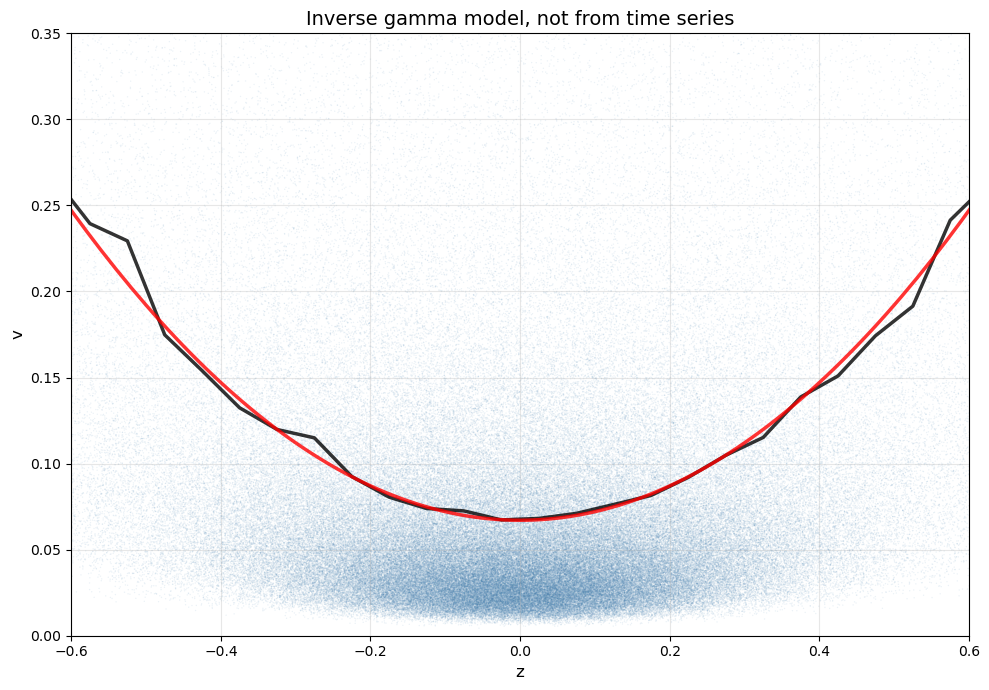

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(df['x'], df['v'], color='steelblue', alpha=0.1, s=1, edgecolors='none')
ax.plot(binned_summary['bin_mid'], binned_summary['v'], color='black', linewidth=2.5, alpha=0.8)
ax.plot(xq, vq, color='red', linewidth=2.5, alpha=0.8)

ax.set_xlim(-0.6, 0.6)
ax.set_ylim(0, 0.35)
ax.set_xlabel('z', fontsize=12)
ax.set_ylabel('v', fontsize=12)

#ax.spines['top'].set_visible(False)
#ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3)

plt.title('Inverse gamma model, not from time series', fontsize=14)
plt.tight_layout()

plt.show()

We next plot variance v versus z^2. In theory the linear coefficient should be 0.5, but this analysis misses the important information that variance should be averaged over each z, and the estimate is subject to noise.

Slope: 0.2450
Intercept: 0.0991
$R^2$: 0.4487


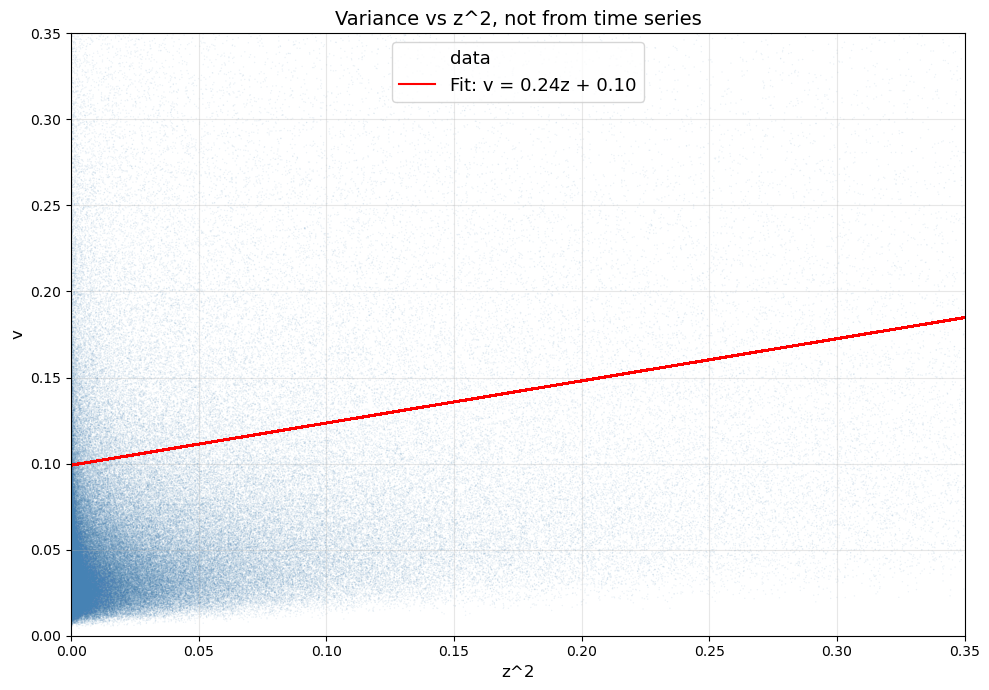

In [12]:
from scipy import stats
df['z2'] = df['x']**2
slope, intercept, r_value, p_value, std_err = stats.linregress(df.z2, df["v"])

# Calculate the regression line values
line = slope * df.z2+ intercept
r_squared = r_value**2

# do confidence intervals
# 1. Regression basics
n = len(df.z2)
dof = n - 2
t_score = stats.t.ppf(0.975, dof) # 95% confidence
v_pred = intercept + slope * df.z2

# 2. Standard Error of the Estimate
residuals = df["v"] - v_pred
s_err = np.sqrt(np.sum(residuals**2) / dof) 

# 3. Calculate intervals
z_mean = np.mean(df.z2)
z_sq_diff = np.sum((df.z2 - z_mean)**2)

# SE for Confidence Interval (the fit)
se_ci = s_err * np.sqrt(1/n + (df.z2 - z_mean)**2 / z_sq_diff)

plt.figure(figsize=(10, 7))
# Scatter plot
plt.scatter(df.z2, df["v"], c='steelblue', alpha=0.1, s=1, edgecolor='none', label='data')
plt.plot(df.z2, line, color='red', label=f'Fit: v = {slope:.2f}z + {intercept:.2f}')
#plt.fill_between(df.z2, v_pred - t_score * se_ci, v_pred + t_score * se_ci,color='red', alpha=0.15, label='95% CI')

# Add a text box for slope, intercept, and R^2
stats_text = f'Slope: {slope:.4f}\nIntercept: {intercept:.4f}\n$R^2$: {r_squared:.4f}'
#plt.text(1, 2.5, stats_text, bbox=dict(facecolor='white', alpha=0.5))
print(stats_text)

plt.xlabel('z^2', fontsize=12)
plt.ylabel('v', fontsize=12)
plt.title('Variance vs z^2, not from time series', fontsize=14)
plt.xlim(0, 0.35)
plt.ylim(0, 0.35)
plt.grid(alpha=0.3)
plt.legend(fontsize=13, loc='upper center')
plt.tight_layout()

plt.show()

## 3. Time series model
Now try to match q-variance by using exponentially distributed intervals.
The variance in each interval is drawn from an inverse-gamma distribution.
The model gives an approximate fit to q-variance.

In [13]:

def get_time_series(M=1e5, avg_length=500, sigma_0_sq=0.01):
    # Interval generation
    raw_T = np.random.exponential(avg_length, size=int(M/avg_length * 2))
    T_j = np.maximum(np.round(raw_T).astype(int), 1)
    
    # Exact fit to M
    cum_T = np.cumsum(T_j)
    idx = np.searchsorted(cum_T, M)
    T_j = T_j[:idx+1]
    T_j[-1] = M - (cum_T[idx-1] if idx > 0 else 0)

    # Variance sampling (Inv-Gamma)
    v_j = 1.0 / np.random.gamma(1.5, 1.0/sigma_0_sq, size=len(T_j))
    
    # Expand variance to time series and sample returns
    v_i = np.repeat(v_j, T_j)
    r_i = np.random.normal(0, np.sqrt(v_i))
    price_path = np.cumsum(r_i)

    return r_i, v_i, price_path

# Parameters
M = n             # Total days e.g. 1e6
avg_length = 2000     # Average days per variance regime
sigma_0 = sig   # boost to give better fit
sigma_0_sq = sigma_0**2/252  # Rate parameter for Inverse-Gamma

log_returns, intervals, variances = get_time_series(M, avg_length, sigma_0_sq)

def get_qvariance(log_returns,HORIZONS):
    rows = []
    scale = np.sqrt(252)
    
    print("Computing Q-Variance curve for T = 1 to 26 weeks...")
    HORIZONS = 5*(np.arange(26)+1)   # does 1 to 26 weeks, can also do [5, 10, 20, 40, 80, 160]
    for T in HORIZONS:
        i = 0
        while i + T <= len(log_returns):
            window = log_returns[i:i+T]     # T points
            if len(window) < T * 0.8:
                break
    
            x = window.sum()   # total price change over the period
            sigma = np.std(window, ddof=0) * scale      # ddof=0 means divisor is N, not N-1
            varcur = sigma**2
            z_raw = x / np.sqrt(T / 252.0)
    
            # REJECT BAD WINDOWS
            if not (np.isfinite(sigma) and sigma > 0 and np.isfinite(z_raw)):
                i += T
                continue
    
            rows.append({          # append row of data for this period
                "T": T,
                "z_raw": float(z_raw),
                "var": float(varcur)
            })
            i += T
    
    df = pd.DataFrame(rows)
    
    # CLEAN BEFORE DE-MEANING 
    df = df[np.isfinite(df['z_raw']) & np.isfinite(df['var']) & (df['var'] > 0)]
    
    # NOW de-mean safely, this step groups by T, and subtracts the group mean 
    df["z"] = df.groupby(["T"])["z_raw"].transform(lambda g: g - g.mean())
    
    df = df.drop(columns="z_raw")
    df = df.dropna().reset_index(drop=True)  # Final clean, can save as e.g. parquet file
    return(df)


HORIZONS = 5*(np.arange(26)+1)   # does 1 to 26 weeks, can also do [5, 10, 20, 40, 80, 160]
df = get_qvariance(log_returns,HORIZONS)
print(f"Generated {len(df["z"]):,} data points")



Computing Q-Variance curve for T = 1 to 26 weeks...
Generated 192,712 data points


## 4. Plot the results from the time series
The model is unstable, so the quality of fit varies.


Q-Variance Fit Results:
  R²   = 0.9633


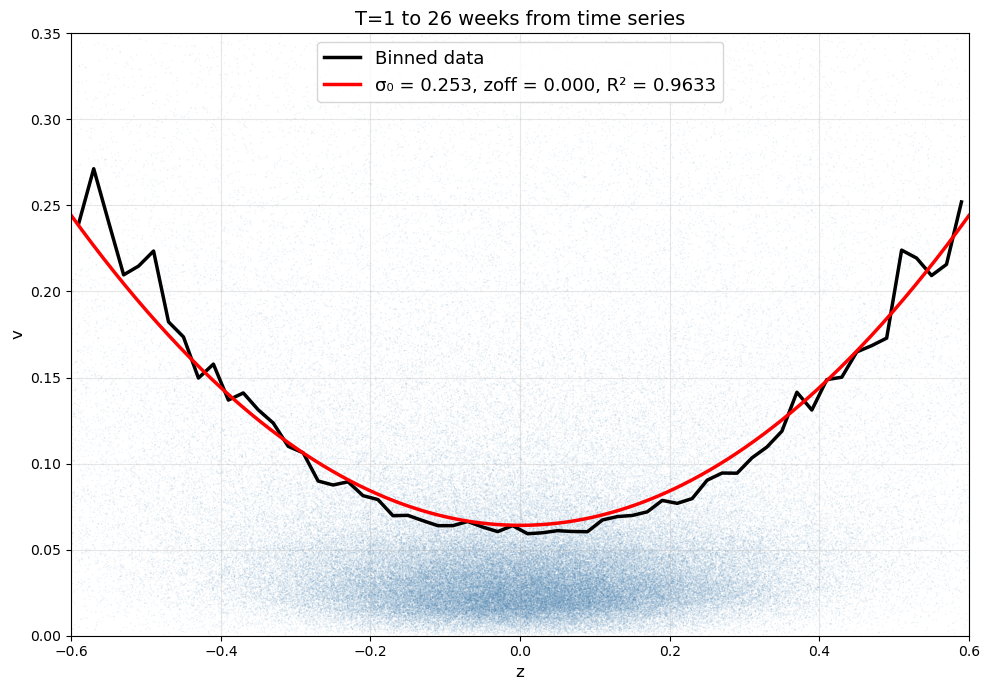

In [14]:
def q_variance_model(z, sigma_0_sq, zoff):
    return sigma_0_sq + (z - zoff)**2 / 2

# Binning
zmax = 0.6
Z_BINS = np.linspace(-zmax, zmax, 61)
bin_means, bin_edges, _ = binned_statistic(df["z"], df["var"], statistic='mean', bins=Z_BINS)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
valid = ~np.isnan(bin_means)

# Fit
popt, pcov = curve_fit(q_variance_model, bin_centers[valid], bin_means[valid],
                       p0=[0.26**2, 0.0], bounds=([0.01, -0.1], [0.5, 0.1]))
sigma_0_sq_fit, zoff_fit = popt
#sigma_0_sq_fit = sigma_0_sq*252  # do not fit, use theoretical curve but annualized
zoff_fit = 0

#perr = np.sqrt(np.diag(pcov))

# R²
#predicted = q_variance_model(bin_centers[valid], *popt)
predicted = q_variance_model(bin_centers[valid], sigma_0_sq_fit, 0)
ss_res = np.sum((bin_means[valid] - predicted)**2)
ss_tot = np.sum((bin_means[valid] - np.mean(bin_means[valid]))**2)
r_squared = 1 - ss_res / ss_tot

print(f"\nQ-Variance Fit Results:")
#print(f"  σ₀   = {sigma_0_sq_fit:.4f} ± {perr[0]:.4f}")
#print(f"  zoff = {zoff_fit:.4f} ± {perr[1]:.4f}")
print(f"  R²   = {r_squared:.4f}")

plt.figure(figsize=(10, 7))

# Scatter plot
plt.scatter(df["z"], df["var"], c='steelblue', alpha=0.1, s=1, edgecolor='none')

# Binned data
plt.plot(bin_centers[valid], bin_means[valid], 'k-', lw=2.5, label='Binned data')

# Q-Variance fit, note results will vary because model is unstable
z_fine = np.linspace(-zmax, zmax, 500)
sigma_0_fit = np.sqrt(sigma_0_sq_fit)
plt.plot(z_fine, q_variance_model(z_fine, sigma_0_sq_fit, 0),
         color='red', lw=2.5,
         label=f'σ₀ = {sigma_0_fit:.3f}, zoff = {zoff_fit:.3f}, R² = {r_squared:.4f}')

plt.xlabel('z', fontsize=12)
plt.ylabel('v', fontsize=12)
plt.title('T=1 to 26 weeks from time series', fontsize=14)
plt.xlim(-0.6, 0.6)
plt.ylim(0, 0.35)
plt.grid(alpha=0.3)
plt.legend(fontsize=13, loc='upper center')
plt.tight_layout()

# Save for publication
# plt.savefig("Q_Variance_Parabola.png", dpi=300, bbox_inches='tight')
# plt.savefig("Q_Variance_Parabola.pdf", bbox_inches='tight')
plt.show()


And a plot of the time series. The instability means that the variance, and therefore price, is sublect to sudden explosions. Such explosions can be controlled by adding extra features such as a cap on variance, but this requires additional parameters. The ultimate problem though is that in the inverse-gamma model, the variance-of-variance is undefined, while in real markets (or the quantum model) the variance-of-variance is finite.

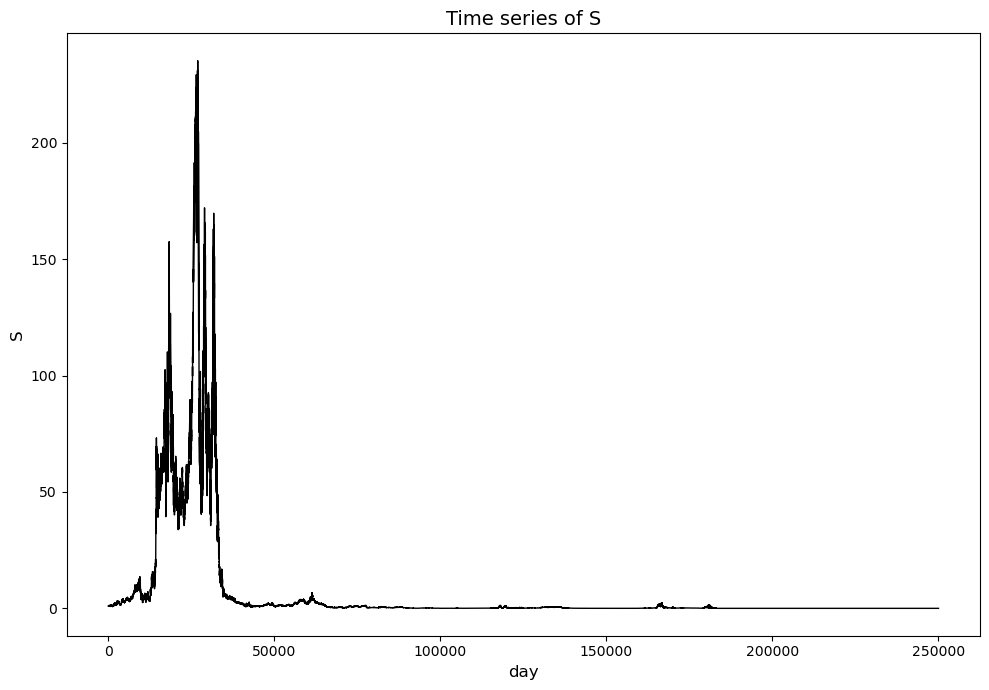

In [15]:
S = np.exp(np.cumsum(log_returns))
plt.figure(figsize=(10, 7))

plt.plot(S, color='black', lw=1, label='S')

plt.xlabel('day', fontsize=12)
plt.ylabel('S', fontsize=12)
plt.title('Time series of S', fontsize=14)
#plt.legend(fontsize=13, loc='upper center')
plt.tight_layout()

plt.show()

## 5. Now check q-variance over a time period of about 20 years
The effect disappears because average variance is driven by extremely rare bursts.

Computing Q-Variance curve for T = 1 to 26 weeks...
Generated 3,836 data points


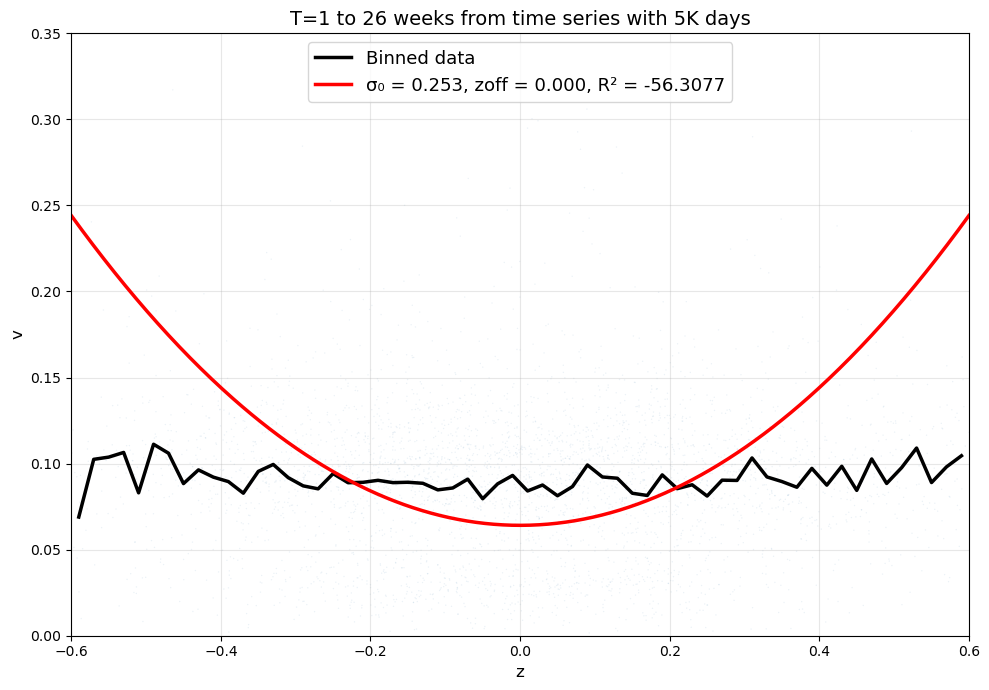

In [16]:
df2 = get_qvariance(log_returns[1:20*250],HORIZONS)
print(f"Generated {len(df2["z"]):,} data points")

plt.figure(figsize=(10, 7))
bin_means, bin_edges, _ = binned_statistic(df2["z"], df2["var"], statistic='mean', bins=Z_BINS)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
valid = ~np.isnan(bin_means)

# Scatter plot
plt.scatter(df2["z"], df2["var"], c='steelblue', alpha=0.1, s=1, edgecolor='none')

# Binned data
plt.plot(bin_centers[valid], bin_means[valid], 'k-', lw=2.5, label='Binned data')

predicted = q_variance_model(bin_centers[valid], sigma_0_sq_fit, 0)
ss_res = np.sum((bin_means[valid] - predicted)**2)
ss_tot = np.sum((bin_means[valid] - np.mean(bin_means[valid]))**2)
r_squared = 1 - ss_res / ss_tot

# Q-Variance fit, note results will vary because model is unstable
z_fine = np.linspace(-zmax, zmax, 500)
sigma_0_fit = np.sqrt(sigma_0_sq_fit)
plt.plot(z_fine, q_variance_model(z_fine, sigma_0_sq_fit, 0),
         color='red', lw=2.5,
         label=f'σ₀ = {sigma_0_fit:.3f}, zoff = {zoff_fit:.3f}, R² = {r_squared:.4f}')

plt.xlabel('z', fontsize=12)
plt.ylabel('v', fontsize=12)
plt.title('T=1 to 26 weeks from time series with 5K days', fontsize=14)
plt.xlim(-0.6, 0.6)
plt.ylim(0, 0.35)
plt.grid(alpha=0.3)
plt.legend(fontsize=13, loc='upper center')
plt.tight_layout()

plt.show()

## 6. Summary
The inverse-gamma model appears to produce q-variance over very long simulations, however the model does not converge reliably, does not hold over relevant time periods such as 20 years, is subject to sudden explosions in variance, and uses too many parameters. The problem is that the inverse-gamma has undefined variance-of-variance, so average variance is determined by extremely rare bursts. This is not the case for either real data, or the quantum model, where the variance-of-variance is non-zero but finite. For a discussion, see the working paper: [Q-Variance: A Quadratic Constraint on Variance.](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=6140027)
